# EDA & Cohort Analysis — Online Retail II

## 1. Carga de datos
Dataset original: 1.067.371 transacciones entre Diciembre 2009 y Diciembre 2011.
Cada fila representa una línea de factura (un producto dentro de una orden).

In [1]:
import pandas as pd
import numpy as np

# Cargar dataset
df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='latin-1')

# Vista general
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras filas:")
df.head()

Shape: (1067371, 8)

Columnas: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Tipos de datos:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

Primeras filas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
print("=== Valores nulos ===")
print(df.isnull().sum())

print("\n=== Facturas con cancelaciones (empiezan con 'C') ===")
print(df[df['Invoice'].astype(str).str.startswith('C')].shape[0])

print("\n=== Precios y cantidades negativas ===")
print("Cantidad negativa:", (df['Quantity'] < 0).sum())
print("Precio negativo:", (df['Price'] < 0).sum())

print("\n=== Rango de fechas ===")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())

=== Valores nulos ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== Facturas con cancelaciones (empiezan con 'C') ===
19494

=== Precios y cantidades negativas ===
Cantidad negativa: 22950
Precio negativo: 5

=== Rango de fechas ===
2009-12-01 07:45:00 → 2011-12-09 12:50:00


## 2. Limpieza de datos

Se eliminaron filas bajo los siguientes criterios:
- **Customer ID nulo** (243.007 filas): sin cliente identificado no es posible analizar retención
- **Facturas canceladas** (prefijo 'C'): representan devoluciones que distorsionan el revenue
- **Cantidad o precio ≤ 0**: registros inválidos o devoluciones no capturadas por el filtro anterior

Dataset resultante: **805.549 filas limpias** (76% del original)

In [3]:
# Copiar el dataframe original para no perderlo
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Customer ID'])

df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

df_clean = df_clean[(df_clean['Price'] > 0) & (df_clean['Quantity'] > 0)]

df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Verificar resultado
print("Filas originales:", df.shape[0])
print("Filas limpias:", df_clean.shape[0])
print("Filas eliminadas:", df.shape[0] - df_clean.shape[0])
print("\nNulos restantes:")
print(df_clean.isnull().sum())

Filas originales: 1067371
Filas limpias: 805549
Filas eliminadas: 261822

Nulos restantes:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [4]:
# Guardar dataset limpio
df_clean.to_csv('../data/processed/retail_clean.csv', index=False)

print("Archivo guardado en data/processed/retail_clean.csv")
print("Shape final:", df_clean.shape)

Archivo guardado en data/processed/retail_clean.csv
Shape final: (805549, 8)


## 3. Carga a MySQL

Se renombraron las columnas a snake_case para alinearlas con el schema definido en MySQL.
La conexión usa variables de entorno via `.env` para no exponer credenciales en el repositorio.

Tabla destino: `customer_retention.transactions`
Filas insertadas: 805.549

In [5]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

df_clean = df_clean.rename(columns={
    'Invoice':     'invoice',
    'StockCode':   'stock_code',
    'Description': 'description',
    'Quantity':    'quantity',
    'InvoiceDate': 'invoice_date',
    'Price':       'price',
    'Customer ID': 'customer_id',
    'Country':     'country'
})

df_clean.to_sql(
    name='transactions',
    con=engine,
    if_exists='append',
    index=False
)

print("Datos cargados correctamente")

Datos cargados correctamente


---
## Próximos pasos

Con los datos limpios y cargados en MySQL, el siguiente paso es el análisis SQL:
- KPIs generales de ventas
- Segmentación de clientes nuevos vs recurrentes
- Construcción de la cohort matrix
- Aproximación de LTV por cohorte

## 4. Insights preliminares

- **Estacionalidad clara**: sep/oct/nov concentran el mayor volumen de órdenes y revenue,
  alineado con el ciclo de compras navideñas.
- **Base de clientes saludable**: los clientes recurrentes superan a los nuevos en todos
  los meses del dataset, indicando buena retención orgánica.
- **Mercado concentrado**: UK e Irlanda dominan el revenue total.

<Axes: title={'center': 'Revenue mensual'}, xlabel='invoice_date'>

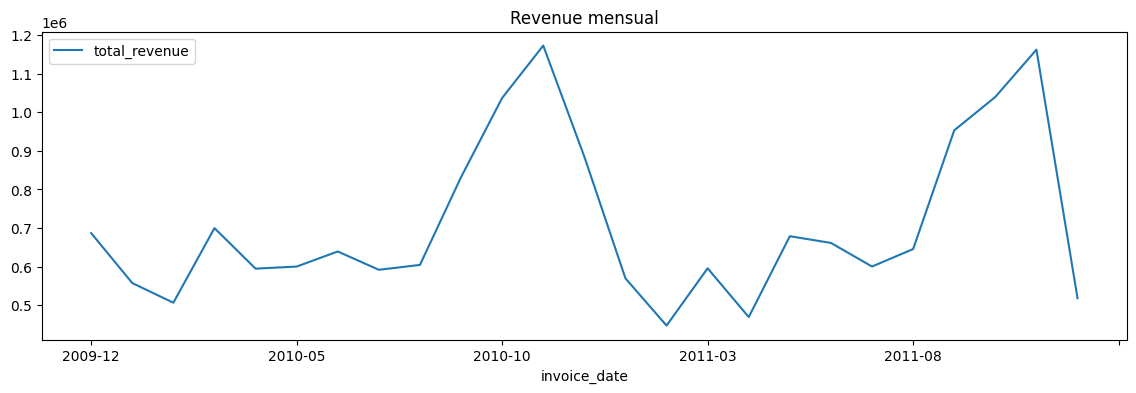

In [6]:
df_clean['revenue'] = df_clean['quantity'] * df_clean['price']

monthly = df_clean.groupby(
    df_clean['invoice_date'].dt.to_period('M')
).agg(
    total_orders=('invoice', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index()

monthly['invoice_date'] = monthly['invoice_date'].astype(str)
monthly.plot(x='invoice_date', y='total_revenue', figsize=(14, 4), title='Revenue mensual')

<Axes: title={'center': 'Nuevos vs Recurrentes por mes'}, xlabel='month'>

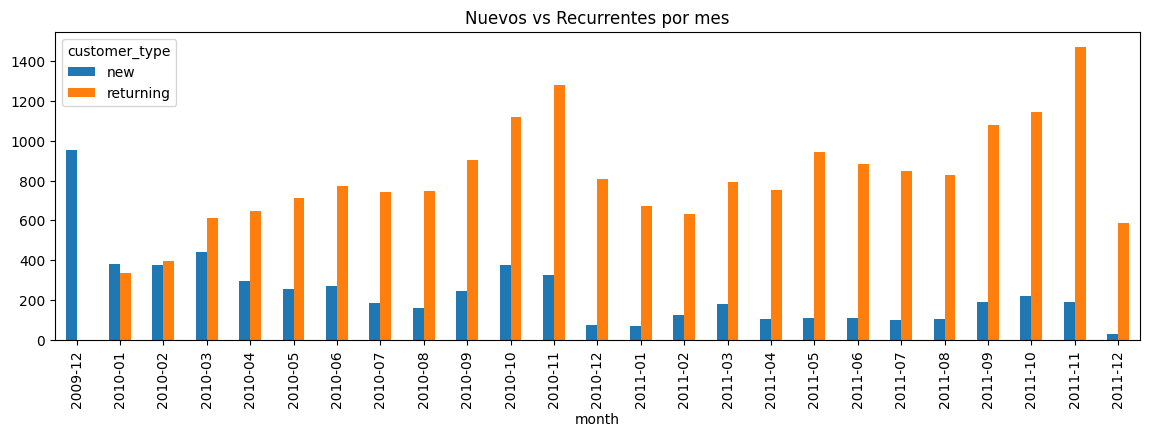

In [7]:
first_purchase = df_clean.groupby('customer_id')['invoice_date'].min().dt.to_period('M')
first_purchase.name = 'cohort_month'

df_cohort = df_clean.join(first_purchase, on='customer_id')
df_cohort['month'] = df_cohort['invoice_date'].dt.to_period('M')
df_cohort['customer_type'] = df_cohort.apply(
    lambda x: 'new' if x['month'] == x['cohort_month'] else 'returning', axis=1
)

customer_type_monthly = df_cohort.groupby(['month', 'customer_type'])['customer_id'].nunique().unstack()
customer_type_monthly.plot(kind='bar', figsize=(14, 4), title='Nuevos vs Recurrentes por mes')

### Insights — Cohort Retention Matrix

- Caída inicial del 65-80% en el primer mes es consistente con el comportamiento típico de retail.
- Las cohortes se estabilizan entre 10-30% de retención a largo plazo.
- La cohorte 2009-12 muestra una reactivación notable en oct/nov 2010, confirmando el efecto estacional.
- Las cohortes de diciembre presentan menor retención futura — clientes de compra única navideña.

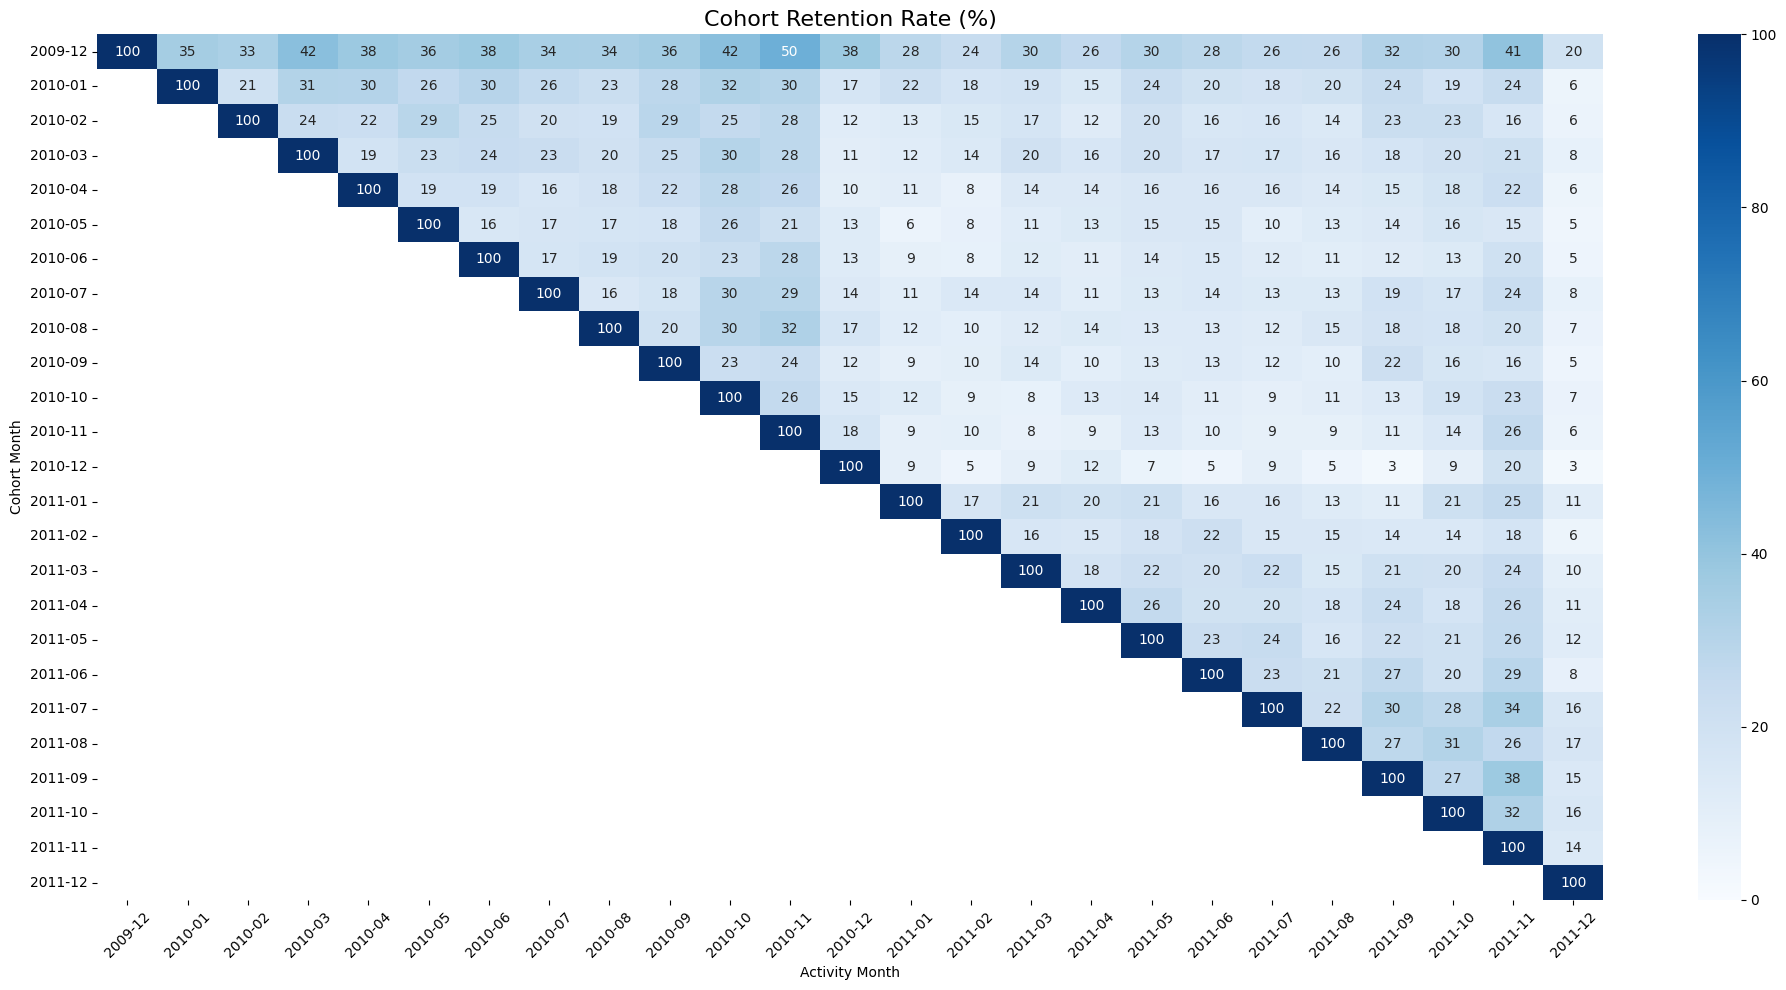

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar resultados de la query
cohort_df = pd.read_csv('../data/processed/retention_rate.csv')

# Pivotear para formar la matriz
cohort_pivot = cohort_df.pivot_table(
    index='cohort_month',
    columns='activity_month',
    values='retention_rate'
)

# Visualizar como heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    vmin=0,
    vmax=100
)
plt.title('Cohort Retention Rate (%)', fontsize=16)
plt.xlabel('Activity Month')
plt.ylabel('Cohort Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights — LTV por Cohorte

- La cohorte 2009-12 tiene el mayor LTV sostenido — clientes tempranos con alta lealtad.
- El gasto por cliente aumenta en oct/nov independientemente de la cohorte, confirmando el efecto estacional no solo en volumen sino en ticket promedio.
- Las cohortes de diciembre muestran alto gasto inicial pero caída abrupta — bajo LTV real.
- El valor atípico de £1556 en 2011-05 requiere investigación adicional — posible concentración en pocos clientes de alto valor.

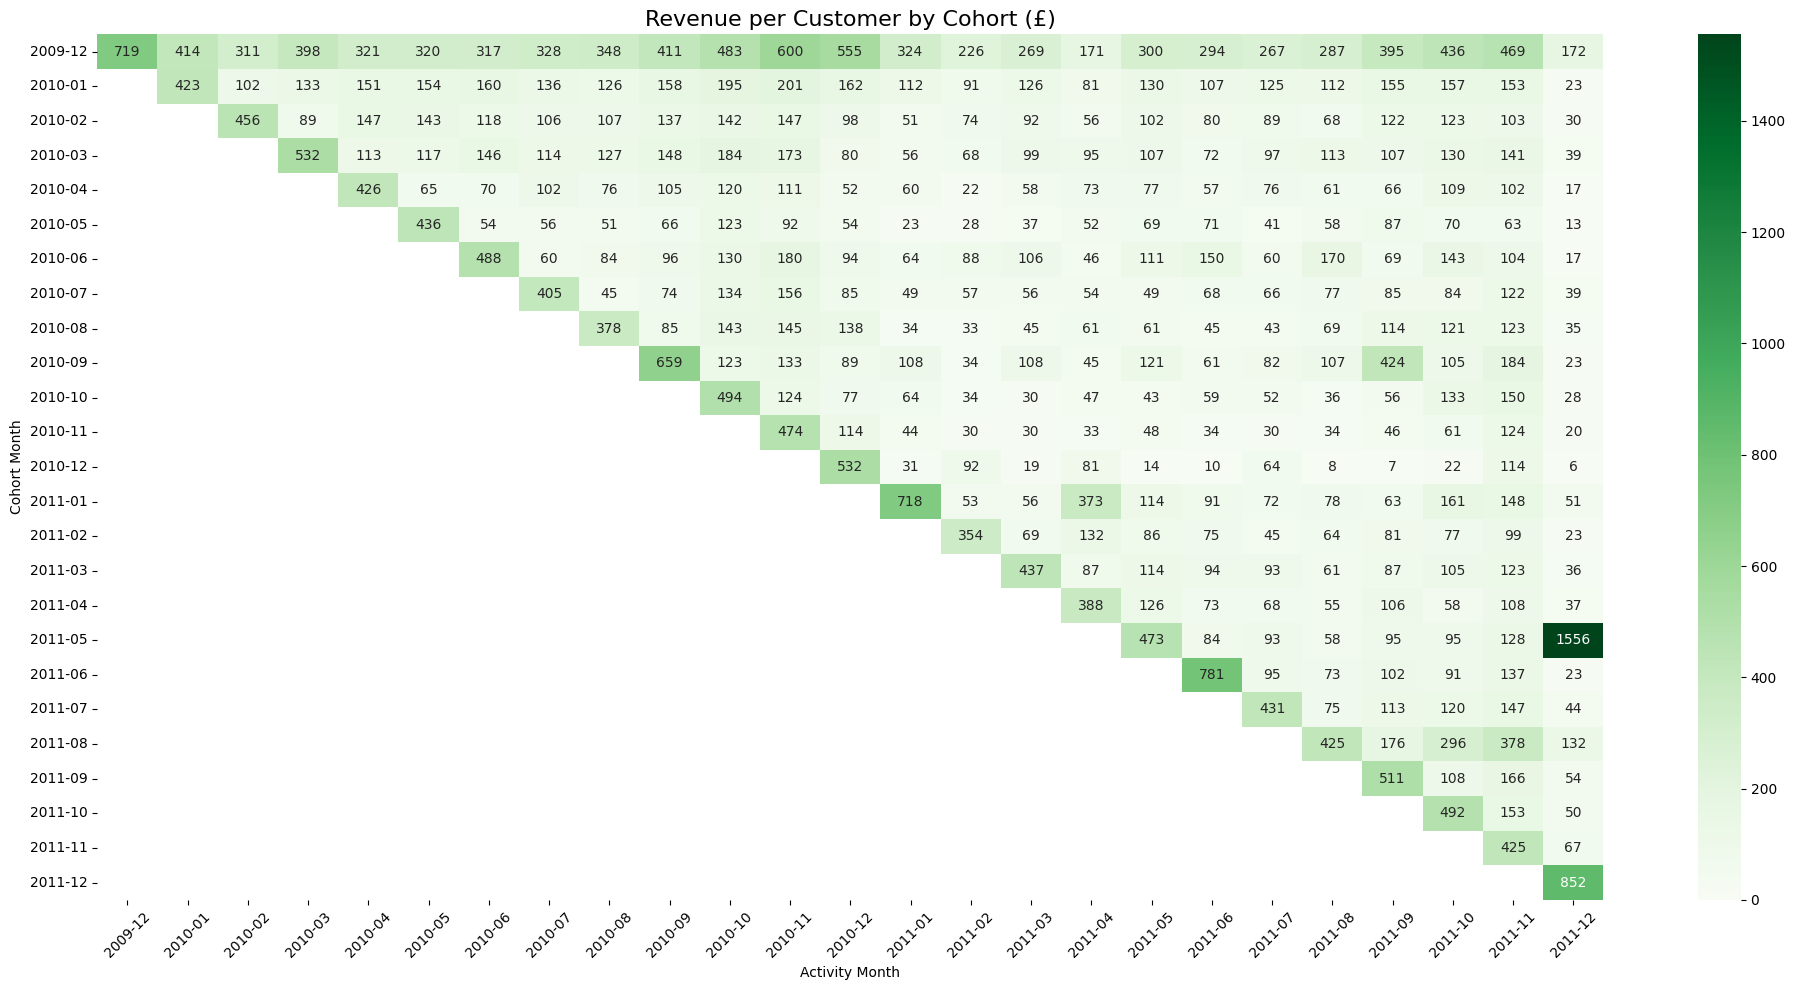

In [9]:
# Cargar datos de LTV
ltv_df = pd.read_csv('../data/processed/ltv_approximation.csv')

# Pivotear revenue por cliente
ltv_pivot = ltv_df.pivot_table(
    index='cohort_month',
    columns='activity_month',
    values='revenue_per_customer'
)

# Heatmap de LTV
plt.figure(figsize=(20, 10))
sns.heatmap(
    ltv_pivot,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    vmin=0
)
plt.title('Revenue per Customer by Cohort (£)', fontsize=16)
plt.xlabel('Activity Month')
plt.ylabel('Cohort Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
print(df_clean['price'].dtype)
print(df_clean['price'].head())

float64
0    6.95
1    6.75
2    6.75
3    2.10
4    1.25
Name: price, dtype: float64
